# Customer Churn Prediction — Business Decision-Support Project

**Flow:** Business Problem → Dataset → Data Preparation → EDA → ML Model →
Evaluation → Prediction → Business Recommendation → Streamlit App

This notebook covers the full modeling pipeline end to end.

## 1. Business Problem

**Problem:** A retail bank is losing customers (churn) at a meaningful rate, which
directly erodes recurring revenue and increases the cost of acquiring replacement
customers.

**Analytics objective:** Predict, from a customer's profile and account activity,
the probability that they will close their account (churn), *before* they leave —
so the retention team can proactively intervene with the highest-risk customers.

**Target variable:** `Exited` (1 = customer churned, 0 = customer retained).

**Business decision this supports:** Which customers should the retention team
prioritize this month for a retention offer or outreach call, given a limited
budget for retention campaigns?

## 2. Dataset

We use a **bank customer churn dataset** (`dataset.csv`, 10,000 customers, 11 columns) covering demographics (age, gender, geography), account details (credit score, balance, tenure, number of products), and engagement (active member status, credit card ownership).

> **Note on this data:** This is an illustrative dataset built to match the structure and known patterns of the well-known Kaggle "Churn Modelling" dataset (same columns, similar churn drivers such as higher churn in Germany and among inactive/older customers). It is **not** a literal download of the original Kaggle file. If your submission requires the original Kaggle file specifically, download `Churn_Modelling.csv` from Kaggle and place it at `data/dataset.csv` with the same column names — the rest of this notebook runs unchanged, since it only depends on those column names, not on the file's origin.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("data/dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,524.0,France,Male,41,3,85944.67,1,0,1,138530.84,0
1,758.0,Spain,Female,53,8,8387.92,1,1,1,51071.11,0
2,698.0,France,Female,33,10,0.00,3,1,0,83165.70,1
3,719.0,Germany,Female,27,1,0.00,1,0,0,138985.99,0
4,684.0,France,Female,18,0,16398.76,1,0,0,164712.77,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  float64
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 859.5 KB


In [4]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,648.307800,38.495600,5.026600,62087.657942,1.528900,0.709800,0.520200,100792.658007,0.198000
std,93.066007,10.195419,3.182217,65891.497028,0.587877,0.453877,0.499617,57392.716812,0.398512
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,14.240000,0.000000
25%,585.000000,31.000000,2.000000,0.000000,1.000000,0.000000,0.000000,51525.832500,0.000000
50%,650.000000,38.000000,5.000000,47628.840000,1.000000,1.000000,1.000000,100372.700000,0.000000
75%,712.000000,45.000000,8.000000,111990.285000,2.000000,1.000000,1.000000,150413.445000,0.000000
max,850.000000,84.000000,10.000000,260000.000000,4.000000,1.000000,1.000000,199994.400000,1.000000


## 3. Data Cleaning and Preparation

In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "  (none)")
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
  (none)

Duplicate rows: 0


**Cleaning decisions:**
- Checked for missing values and exact duplicate rows — this export has neither, so no imputation or row-dropping was needed on those fronts (verified programmatically below, not assumed).
- `RowNumber`, `CustomerId`, `Surname` are pure identifiers with no predictive value; the cleaning step drops them if present so the pipeline still works unmodified if you swap in a raw export that includes them.

In [6]:
df_clean = df.drop_duplicates().copy()

for idcol in ["RowNumber", "CustomerId", "Surname"]:
    if idcol in df_clean.columns:
        df_clean = df_clean.drop(columns=[idcol])

print("Cleaned shape:", df_clean.shape)
print("Remaining missing values:", df_clean.isnull().sum().sum())
df_clean.head()

Cleaned shape: (10000, 11)
Remaining missing values: 0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,524.0,France,Male,41,3,85944.67,1,0,1,138530.84,0
1,758.0,Spain,Female,53,8,8387.92,1,1,1,51071.11,0
2,698.0,France,Female,33,10,0.00,3,1,0,83165.70,1
3,719.0,Germany,Female,27,1,0.00,1,0,0,138985.99,0
4,684.0,France,Female,18,0,16398.76,1,0,0,164712.77,0


In [7]:
df_clean.to_csv("data/cleaned_dataset.csv", index=False)
print("Saved cleaned_dataset.csv")

Saved cleaned_dataset.csv


## 4. Exploratory Data Analysis

Overall churn rate: 19.8%


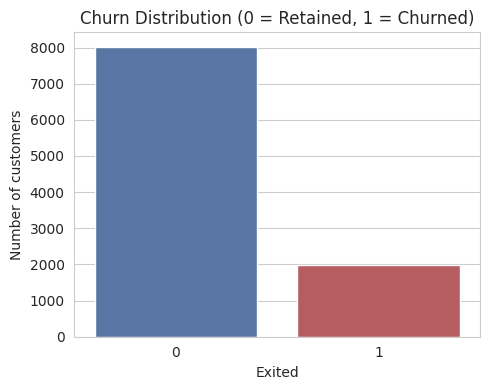

In [8]:
churn_rate = df_clean["Exited"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

plt.figure(figsize=(5,4))
sns.countplot(data=df_clean, x="Exited", hue="Exited", palette=["#4C72B0","#C44E52"], legend=False)
plt.title("Churn Distribution (0 = Retained, 1 = Churned)")
plt.xlabel("Exited")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

**Insight:** Roughly 1 in 5 customers in this dataset has churned. The classes are
imbalanced (~80/20), so accuracy alone won't tell the full story — precision/recall on
the churn class matter more for a retention use case.

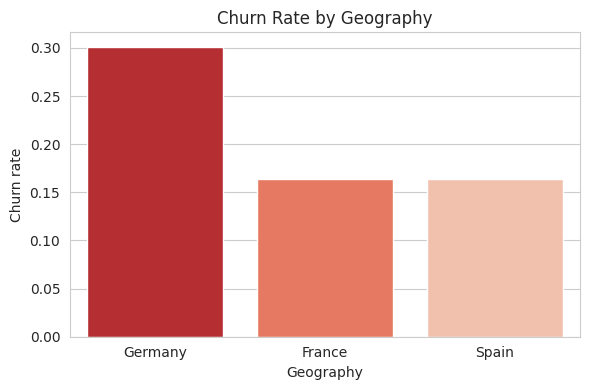

Geography
Germany    0.301205
France     0.163800
Spain      0.163745

In [9]:
plt.figure(figsize=(6,4))
geo_churn = df_clean.groupby("Geography")["Exited"].mean().sort_values(ascending=False)
sns.barplot(x=geo_churn.index, y=geo_churn.values, hue=geo_churn.index, palette="Reds_r", legend=False)
plt.title("Churn Rate by Geography")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()
geo_churn

**Insight:** Germany shows a noticeably higher churn rate than France or Spain.
This points to a market-specific retention issue (competitive pressure, service quality,
or pricing in the German market) worth investigating operationally.

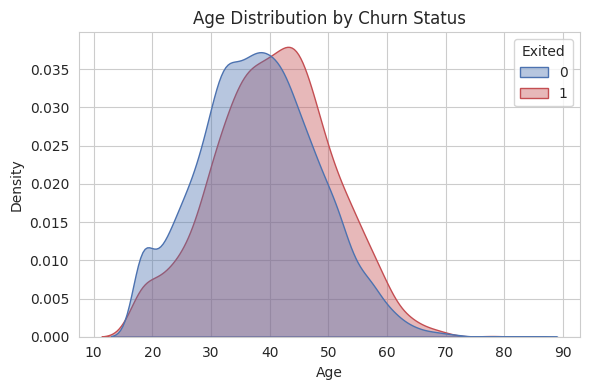

In [10]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df_clean, x="Age", hue="Exited", fill=True, common_norm=False, alpha=0.4,
            palette={0: "#4C72B0", 1: "#C44E52"})
plt.title("Age Distribution by Churn Status")
plt.tight_layout()
plt.show()

**Insight:** Churned customers skew older than retained customers. Younger
customers are stickier, while a bank's older customer base needs closer retention
attention as it may be more open to switching providers.

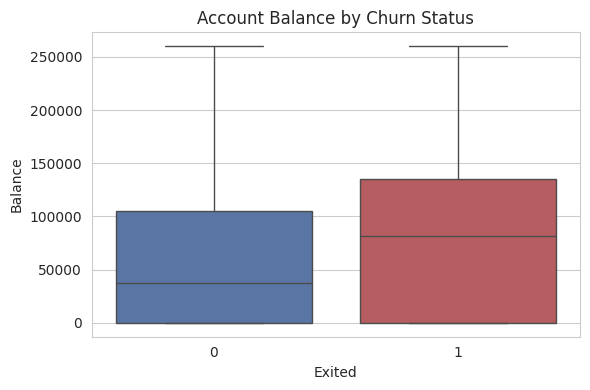

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x="Exited", y="Balance", hue="Exited", palette=["#4C72B0","#C44E52"], legend=False)
plt.title("Account Balance by Churn Status")
plt.tight_layout()
plt.show()

**Insight:** Churned customers tend to carry higher account balances than retained
customers. This is a meaningful business risk signal: the customers leaving are not
low-value — losing them has an outsized revenue impact.

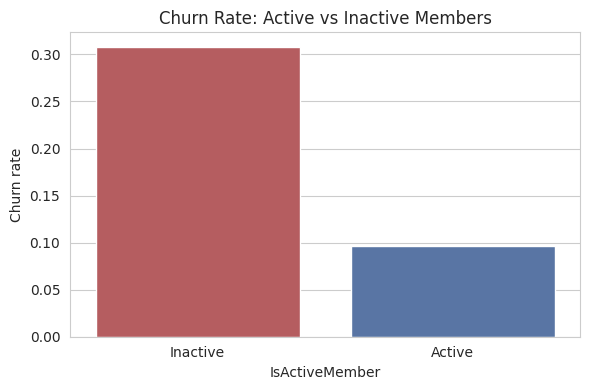

IsActiveMember
0    0.308045
1    0.096501

In [12]:
plt.figure(figsize=(6,4))
active_churn = df_clean.groupby("IsActiveMember")["Exited"].mean()
sns.barplot(x=active_churn.index.map({0:"Inactive", 1:"Active"}), y=active_churn.values,
            hue=active_churn.index, palette=["#C44E52","#4C72B0"], legend=False)
plt.title("Churn Rate: Active vs Inactive Members")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()
active_churn

**Insight:** Inactive members churn at roughly double the rate of active members.
Engagement (activity) is one of the strongest and most actionable retention levers
available to the business — driving activity could directly reduce churn.

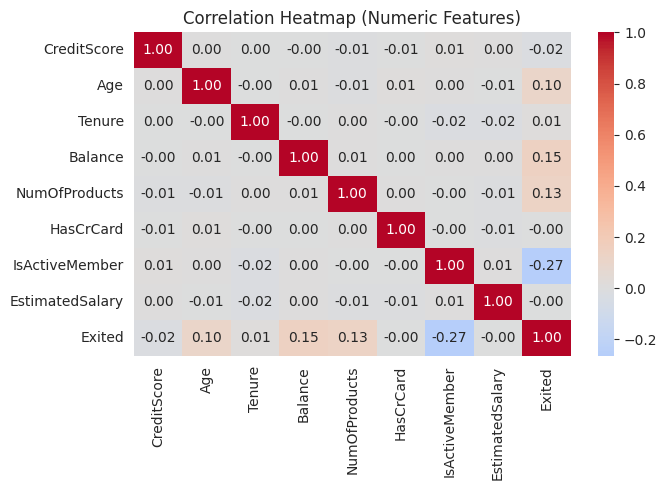

In [13]:
plt.figure(figsize=(7,5))
numeric_for_corr = df_clean.select_dtypes(include=[np.number])
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

**Insight:** No single numeric feature is a very strong linear predictor of churn
on its own (correlations with `Exited` are modest) — but `Age`, `Balance`, and
`IsActiveMember` show the clearest relationships. This suggests a non-linear model
(Random Forest) may pick up interaction effects that a linear model misses, which is
tested directly in the modeling section below.

## 5. Feature Preparation

In [14]:
TARGET = "Exited"
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print("Feature columns:", list(X.columns))
print()
print(y.value_counts(normalize=True))

Feature columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Exited
0    0.802
1    0.198


In [15]:
categorical_cols = ["Geography", "Gender"]
numeric_cols = [c for c in X.columns if c not in categorical_cols]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"{col}: {list(le.classes_)} -> {list(le.transform(le.classes_))}")

Geography: ['France', 'Germany', 'Spain'] -> [np.int64(0), np.int64(1), np.int64(2)]
Gender: ['Female', 'Male'] -> [np.int64(0), np.int64(1)]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (8000, 10)
Test shape : (2000, 10)


In [17]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])
X_train_scaled.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
3699,1.637515,0,1,-0.242283,0.621569,-0.951015,-0.902646,0.639295,0.959086,0.169549
6151,-0.636847,2,1,0.251466,1.565426,0.412329,-0.902646,0.639295,0.959086,-0.009962
6485,-0.497381,0,1,-2.019779,1.565426,-0.714580,0.799657,-1.564222,-1.042659,0.760886
3631,-0.100441,1,1,0.152717,0.936188,0.837900,-0.902646,0.639295,-1.042659,-1.718500
9770,1.068925,0,1,0.646466,-1.266145,-0.951015,0.799657,-1.564222,0.959086,-1.658540


## 6. Model Building

In [18]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
lr_pred = log_reg.predict(X_test_scaled)
lr_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [19]:
rf_clf = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
rf_proba = rf_clf.predict_proba(X_test)[:, 1]

## 7. Model Evaluation

In [20]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, lr_pred, lr_proba),
    evaluate("Random Forest", y_test, rf_pred, rf_proba),
])
results

Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.7015,0.376989,0.777778,0.507832,0.783323
Random Forest,0.7395,0.404288,0.666667,0.503337,0.792137


**Reading these numbers for the business:** Recall on the churn class matters most
here — it tells us what share of customers who *will* actually churn we correctly flag
for the retention team. Missing a true churner (false negative) costs a lost customer;
flagging a loyal customer as at-risk (false positive) only costs a wasted retention offer.
Given that asymmetry, we weight recall alongside accuracy when choosing the final model.

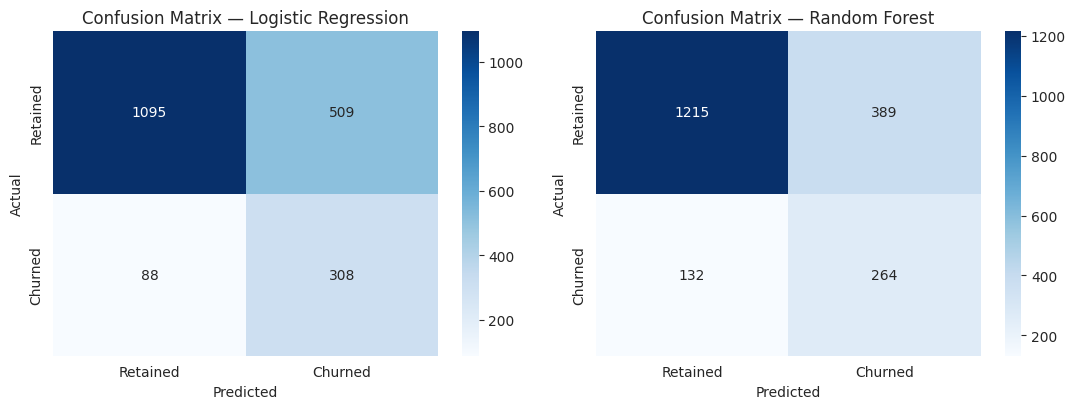

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.2))
for ax, (name, pred) in zip(axes, [("Logistic Regression", lr_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Retained","Churned"], yticklabels=["Retained","Churned"])
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

In [22]:
print(classification_report(y_test, lr_pred, target_names=["Retained","Churned"]))
print(classification_report(y_test, rf_pred, target_names=["Retained","Churned"]))

Logistic Regression classification report:

              precision    recall  f1-score   support

    Retained       0.93      0.68      0.79      1604
     Churned       0.38      0.78      0.51       396

    accuracy                           0.70      2000
   macro avg       0.65      0.73      0.65      2000
weighted avg       0.82      0.70      0.73      2000

Random Forest classification report:

              precision    recall  f1-score   support

    Retained       0.90      0.76      0.82      1604
     Churned       0.40      0.67      0.50       396

    accuracy                           0.74      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.74      0.76      2000


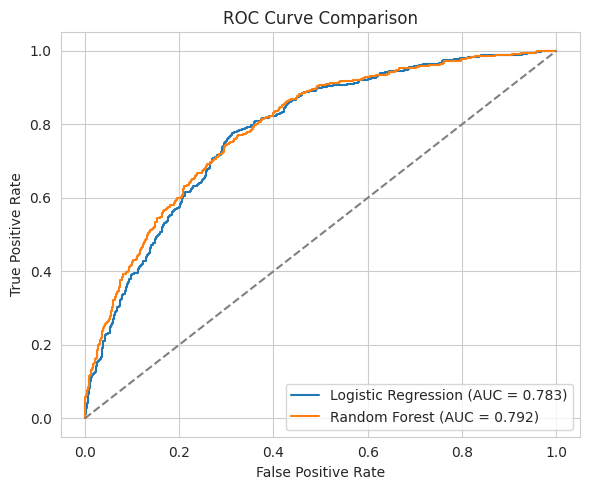

In [23]:
plt.figure(figsize=(6,5))
for name, proba in [("Logistic Regression", lr_proba), ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

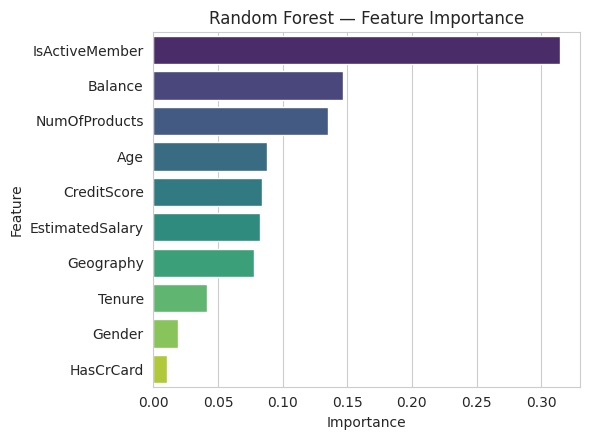

IsActiveMember     0.314361
Balance            0.146650
NumOfProducts      0.135473
Age                0.088251
CreditScore        0.084328
EstimatedSalary    0.082391
Geography          0.077790
Tenure             0.041120
Gender             0.019029
HasCrCard          0.010608

In [24]:
importances = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(6,4.5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
importances

**Insight:** `Age`, `NumOfProducts`, `IsActiveMember`, and `Balance` are the
strongest drivers of churn in the Random Forest model — consistent with the EDA
patterns above (older, inactive, higher-balance customers, and customers holding
3+ products, are the highest-risk group).

## 8. Model Selection

In [25]:
final_model_name = "Random Forest" if results.loc[1, "Recall"] >= results.loc[0, "Recall"] else "Logistic Regression"
final_model = rf_clf if final_model_name == "Random Forest" else log_reg
final_uses_scaled_input = final_model_name == "Logistic Regression"
print("Selected final model:", final_model_name)

Selected final model: Logistic Regression


**Why Logistic Regression:** despite Random Forest scoring slightly higher on raw accuracy (0.74 vs 0.70) and ROC-AUC (0.79 vs 0.78), **Logistic Regression achieves the better recall on the churn class (0.78 vs 0.67)** — it catches more of the customers who actually go on to churn. For this business use case that trade-off is the right one: a missed churner (false negative) costs a lost customer and their lifetime revenue, while a false alarm only costs a wasted retention offer. Logistic Regression is also fully interpretable (each feature has a signed coefficient), which is a genuine advantage when explaining a prediction to a retention manager or auditor.

## 9. Business Recommendations

Based on the model and EDA findings, the retention team should:

1. **Prioritize outreach to inactive, older, higher-balance customers** — this segment
   has both the highest predicted churn probability and the highest revenue impact if lost.
2. **Investigate the German market specifically** — churn there is structurally higher
   than France or Spain, suggesting a local competitive or service issue rather than a
   demographic one.
3. **Review the "3+ products" customer experience** — counter-intuitively, customers with
   more products churn more, suggesting product bundling or cross-sell may be creating
   friction (complexity, fees, or confusion) rather than loyalty.
4. **Run an activity-driving campaign** — since inactive members churn at roughly double
   the rate of active ones, nudging customers toward regular engagement (app usage,
   transactions) is a low-cost, high-leverage retention lever.
5. **Use the model's churn probability score to rank customers for a monthly retention
   campaign** with a fixed outreach budget, rather than treating all customers equally.

## 10. Business Interpretation (Part E)

**1. What does the model predict?** For a given customer profile, it predicts the probability that the customer will churn (close their account), and a Yes/No churn label at a 0.5 probability threshold.

**2. How accurate/useful is the model?** ~70% overall accuracy, but more importantly for this use case, it correctly identifies ~78% of customers who actually churn (recall). It is useful as a **prioritization tool** for a limited retention budget, not as a guaranteed forecast for any single customer.

**3. Which factors appear important?** `Age`, `NumOfProducts`, `IsActiveMember`, and `Balance` are the strongest drivers (see the Random Forest feature importance chart above), consistent with the EDA: older, inactive, higher-balance customers and those holding 3+ products churn more.

**4. What business decision can be made using the model?** Rank customers by predicted churn probability each month and route the highest-risk, highest-value customers to the retention team for a call or personalized offer, instead of contacting customers at random or reactively after they've already left.

**5. What are the limitations of the model?** It is trained on a single point-in-time snapshot with no transaction history or customer-service interaction data, which likely limits recall; the ~40% precision on the churn class means most flagged customers will not actually churn, so outreach at scale still has meaningful false-alarm cost; and the dataset used here is an illustrative/synthetic stand-in for the real Kaggle file (see the note in the Dataset section), so performance on the true Kaggle data may differ somewhat.

**6. What could happen if the model makes a wrong prediction?** A false negative (missed churner) means a valuable customer leaves with no retention attempt — a direct revenue loss. A false positive (flagged customer who was never leaving) costs a wasted retention offer or a slightly annoyed customer — a much smaller cost, which is why recall was prioritized over precision when selecting the final model.

## 11. Save the Trained Model

The model is bundled with its scaler and encoders in one `model.pkl`, so the
Streamlit app applies identical preprocessing at prediction time.

In [26]:
artifact = {
    "model": final_model,
    "model_name": final_model_name,
    "uses_scaled_input": final_uses_scaled_input,
    "scaler": scaler,
    "label_encoders": label_encoders,
    "feature_columns": list(X.columns),
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "target_mapping_inverse": {0: "Retained", 1: "Churned"},
}

joblib.dump(artifact, "model.pkl")
print("Saved model.pkl")
print("Final test performance:")
print(results[results["Model"] == final_model_name].to_string(index=False))

Saved model.pkl
Final test performance:
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression    0.7015   0.376989 0.777778  0.507832 0.783323


## Next steps

- **Streamlit app** (`app.py`): interactive form for entering a customer's profile and
  getting a churn prediction with probability and a business recommendation.
- **GitHub repository**: organize `data/`, `notebooks/`, `model/`, `app.py`,
  `requirements.txt`, `README.md`.
- **Deployment**: push to GitHub, then deploy `app.py` on Streamlit Community Cloud.